In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


Wygenerowanie danych wejściowych

In [33]:
observations=100000

xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs=np.column_stack((xs,zs))

print(inputs.shape)

(100000, 2)


Ustawienie odchyłki w danych (noise) i ustalenie celu (targets) do jakich ma dążyć model

Zapisanie danych wejściowych i celu w formacie Tensorflow

In [34]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 13*xs - 23*zs + 4 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(100000, 1)


Wizualizacja danych

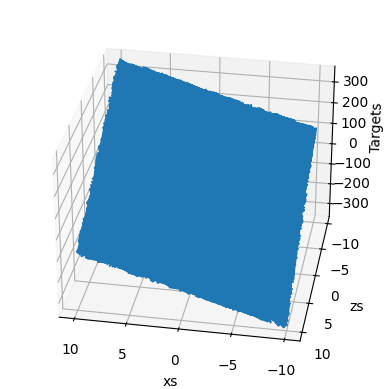

In [5]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations)
zs = zs.reshape(observations)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

Ustawienie pierwszych wag i biasu

In [35]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print("Początkowe wagi: ", weights)
print("Początkowy bias: ", biases)

Początkowe wagi:  [[-0.04532065]
 [-0.05744565]]
Początkowy bias:  [0.09954239]


Uczenie modelu

In [36]:
targets = targets.reshape(observations,1)
eta = 0.001
for i in range(1000): #epoki
  outputs = np.dot(inputs, weights)
  deltas = outputs - targets

  losse = np.sum(deltas ** 2)/2/observations
  print(losse)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

11605.197408334148
10845.650946044647
10135.851005210581
9472.539425859715
8852.67144261188
8273.401708265503
7732.071232780975
7226.195177706014
6753.451450014884
6311.6700430031515
5898.823075308801
5513.01548233526
5152.476317346576
4815.550622303811
4500.6918311267855
4206.45467050959
3931.488525702066
3674.5312408039285
3434.4033251127285
3210.0025389308025
3000.298833978245
2804.329625186664
2621.195372169672
2450.055450087582
2290.1242909522016
2140.6677776590623
2000.9998741944719
1870.4794765489703
1748.5074698818585
1634.523978428217
1528.0057955246348
1428.4639819566216
1335.4416216033953
1248.5117240777076
1167.2752647332038
1091.3593530423284
1020.4155209370692
954.1181232554989
892.1628429516898
834.2652942074457
780.1597170337278
729.5977573696042
682.3473270790183
638.1915386124189
596.9277094430495
558.3664317079619
522.3307027831437
488.65511280184904
457.18508538661666
427.7761681097149
400.293369425029
374.6105390277333
350.6097887974166
328.18095166663977
307.22107

Sprawdzenie wag i biasu jakich nauczył się model

In [37]:
print("Wagi: ", weights)
print("Bias: ", biases)

Wagi:  [[ 12.99987284]
 [-22.99875884]]
Bias:  [4.08957357]


Wizualizacja danych wyściowych z modelu do naszego celu

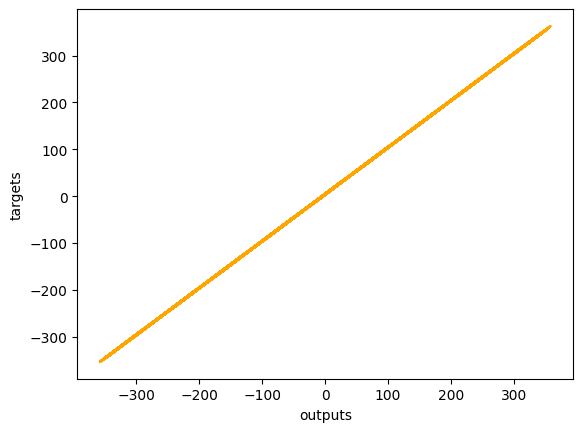

In [38]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()